# Credit Card Fraud Detection & Transaction Analytics

**Goal:** detect fraudulent credit card transactions in a highly imbalanced dataset (~0.17% fraud) and analyse fraud patterns.

**Dataset:** [Kaggle – Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). 284,807 European card transactions over 2 days. `V1`–`V28` are PCA-anonymised features; `Time` = seconds since the first transaction; `Amount` = transaction value; `Class` = 1 for fraud.

**Pipeline:** cleaning → feature engineering → EDA → stratified split → 3 models → cross-validation → threshold tuning → business-impact analysis → feature importance → save model → load into MySQL for SQL analytics.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, average_precision_score,
                             roc_auc_score, precision_recall_curve)
from sklearn.inspection import permutation_importance
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load & clean

In [7]:
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)
print(df["Class"].value_counts())
print(f"Fraud rate: {df['Class'].mean() * 100:.3f}%")

Missing values: 0
Duplicate rows: 1081
Shape after dropping duplicates: (283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate: 0.167%


## 2. Feature engineering
- `Hour`: hour of day derived from `Time` (seconds since the first transaction)
- `Day`: day 0 or day 1 of the 2-day window
- `LogAmount`: `Amount` is heavily right-skewed, so log-transform it

In [11]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Day"] = (df["Time"] // 86400).astype(int)
df["LogAmount"] = np.log1p(df["Amount"])
df[["Time", "Hour", "Day", "Amount", "LogAmount"]].describe()

,Time,Hour,Day,Amount,LogAmount
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,14.045646,0.491636,88.472687,3.153760
std,47481.047891,5.834817,0.499931,250.399437,1.657080
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54204.750000,10.000000,0.000000,5.600000,1.887070
50%,84692.500000,15.000000,0.000000,22.000000,3.135494
75%,139298.000000,19.000000,1.000000,77.510000,4.363226
max,172792.000000,23.000000,1.000000,25691.160000,10.153941


## 3. Exploratory data analysis

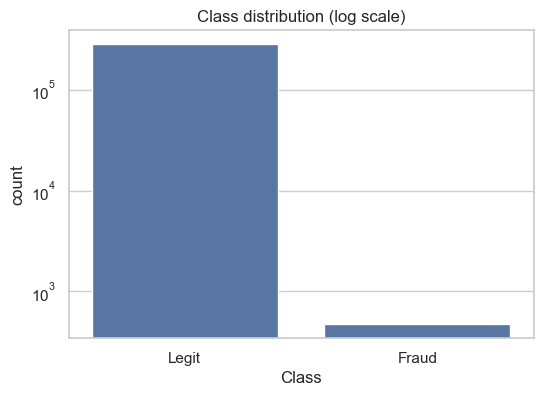

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="Class", data=df, ax=ax)
ax.set_yscale("log")
ax.set_xticks([0, 1], ["Legit", "Fraud"])
ax.set_title("Class distribution (log scale)")
plt.show()

### Transaction amount: fraud vs legit

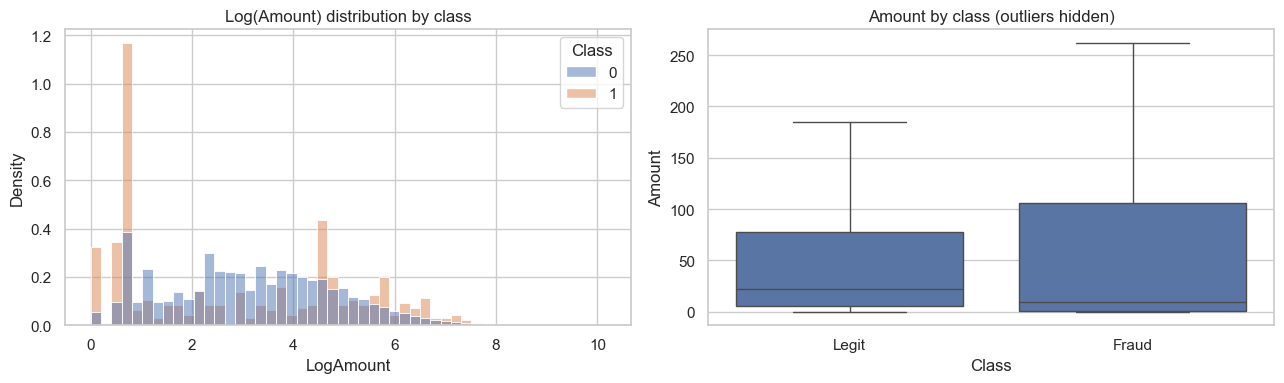

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="LogAmount", hue="Class", stat="density", common_norm=False, bins=50, ax=axes[0])
axes[0].set_title("Log(Amount) distribution by class")
sns.boxplot(data=df, x="Class", y="Amount", showfliers=False, ax=axes[1])
axes[1].set_xticks([0, 1], ["Legit", "Fraud"])
axes[1].set_title("Amount by class (outliers hidden)")
plt.tight_layout()
plt.show()

df.groupby("Class")["Amount"].describe()

### Fraud by hour of day

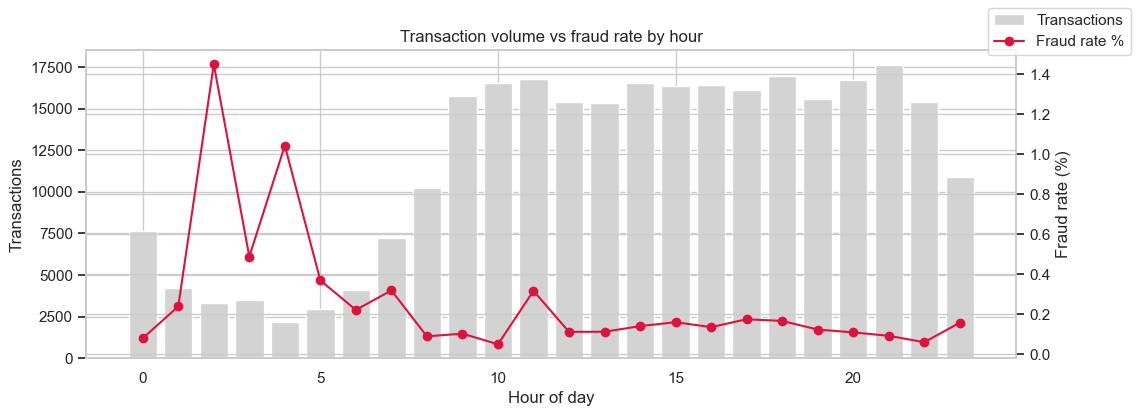

,transactions,frauds,fraud_rate_pct
Hour,,,
2.0,3308,48,1.451028
4.0,2204,23,1.043557
3.0,3487,17,0.487525
5.0,2988,11,0.368139
7.0,7233,23,0.317987


In [17]:
hourly = df.groupby("Hour").agg(transactions=("Class", "size"), frauds=("Class", "sum"))
hourly["fraud_rate_pct"] = hourly["frauds"] / hourly["transactions"] * 100

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(hourly.index, hourly["transactions"], color="lightgray", label="Transactions")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Transactions")
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["fraud_rate_pct"], color="crimson", marker="o", label="Fraud rate %")
ax2.set_ylabel("Fraud rate (%)")
ax1.set_title("Transaction volume vs fraud rate by hour")
fig.legend(loc="upper right")
plt.show()

hourly.sort_values("fraud_rate_pct", ascending=False).head()

> **Write your observation here** (e.g. which hours have low volume but a high fraud rate).

### Which features separate fraud from legit?

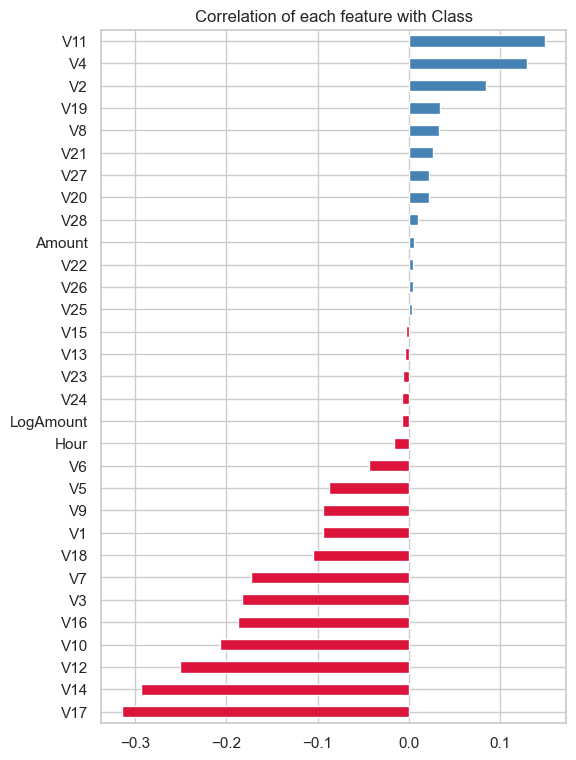

Most correlated features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


In [19]:
corr = df.drop(columns=["Time", "Day"]).corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(6, 9))
corr.plot(kind="barh", color=["crimson" if v < 0 else "steelblue" for v in corr])
plt.title("Correlation of each feature with Class")
plt.show()

top_features = corr.abs().sort_values(ascending=False).head(6).index.tolist()
print("Most correlated features:", top_features)

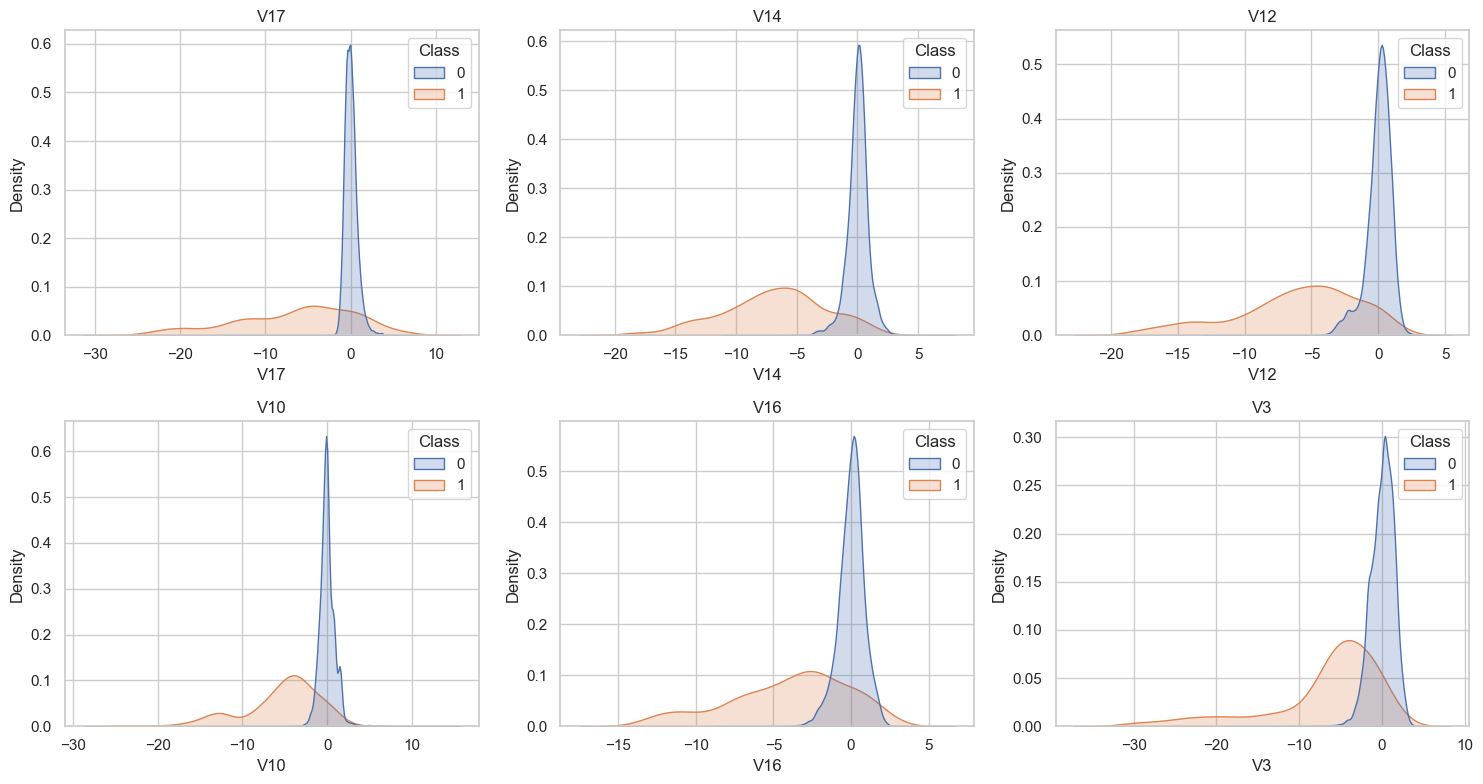

In [21]:
# Sample legit rows so the KDE plots are fast and readable
plot_df = pd.concat([df[df["Class"] == 1], df[df["Class"] == 0].sample(20000, random_state=RANDOM_STATE)])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, top_features):
    sns.kdeplot(data=plot_df, x=col, hue="Class", common_norm=False, fill=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Stratified train/test split
`stratify=y` keeps the fraud ratio identical in train and test. Without it the ~0.17% minority class can be unevenly split.

In [23]:
features = [c for c in df.columns if c not in ["Class", "Time", "Amount", "Day"]]
X = df[features]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "frauds:", y_train.sum())
print("Test: ", X_test.shape, "frauds:", y_test.sum())

Train: (226980, 30) frauds: 378
Test:  (56746, 30) frauds: 95


## 5. Model comparison
Accuracy is misleading here (predicting "legit" for everything gives ~99.8%). I evaluate with:
- **PR-AUC (average precision)**: the main metric for imbalanced data
- **ROC-AUC**
- **Precision / Recall / F1** for the fraud class at the default 0.5 threshold

Logistic Regression is wrapped in a pipeline with `StandardScaler` (this fixes the earlier convergence warning). Tree models don't need scaling.

In [25]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.1, class_weight="balanced", random_state=RANDOM_STATE,
    ),
}

results, probas = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    probas[name] = p
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    results.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_test, p),
        "ROC-AUC": roc_auc_score(y_test, p),
        "Precision": tp / (tp + fp) if tp + fp else 0,
        "Recall": tp / (tp + fn),
        "F1": 2 * tp / (2 * tp + fp + fn),
        "False positives": fp,
        "Missed frauds": fn,
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,PR-AUC,ROC-AUC,Precision,Recall,F1,False positives,Missed frauds
Model,,,,,,,
Logistic Regression,0.6810,0.9623,0.0547,0.8737,0.1030,1434,12
Random Forest,0.8137,0.9437,0.9583,0.7263,0.8263,3,26
Hist Gradient Boosting,0.7242,0.9663,0.3391,0.8211,0.4800,152,17


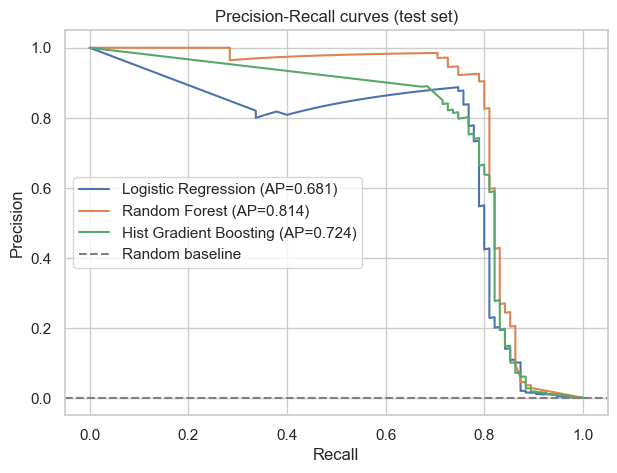

In [51]:
plt.figure(figsize=(7, 5))
for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, p):.3f})")
plt.axhline(y_test.mean(), color="gray", linestyle="--", label="Random baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (test set)")
plt.legend()
plt.show()

## 6. Cross-validation
The test set has only ~95 frauds, so one split is noisy. 5-fold stratified CV on the training set gives a more reliable comparison.
*(Takes a few minutes.)*

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    cv_rows.append({"Model": name, "CV PR-AUC mean": scores.mean(), "CV PR-AUC std": scores.std()})
pd.DataFrame(cv_rows).set_index("Model").round(4)

,CV PR-AUC mean,CV PR-AUC std
Model,,
Logistic Regression,0.7560,0.0270
Random Forest,0.8402,0.0340
Hist Gradient Boosting,0.7475,0.0216


## 7. Threshold tuning
A 0.5 cut-off is arbitrary. I pick the threshold that maximises F1 using **out-of-fold predictions on the training set**, then apply it once to the test set. This keeps the test set untouched by tuning decisions.

Best model: Random Forest
Chosen threshold: 0.310 (train OOF precision=0.891, recall=0.825)


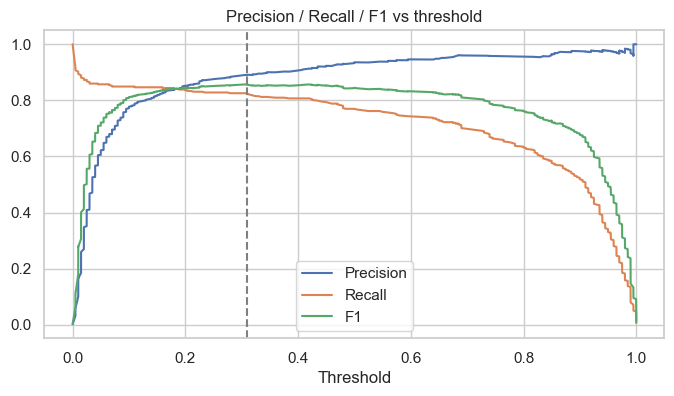

In [28]:
best_name = results_df["PR-AUC"].idxmax()
best_model = models[best_name]
print("Best model:", best_name)

oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.argmax(f1s[:-1])
best_threshold = thr[best_idx]
print(f"Chosen threshold: {best_threshold:.3f} (train OOF precision={prec[best_idx]:.3f}, recall={rec[best_idx]:.3f})")

plt.figure(figsize=(8, 4))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.plot(thr, f1s[:-1], label="F1")
plt.axvline(best_threshold, color="gray", linestyle="--")
plt.xlabel("Threshold")
plt.title("Precision / Recall / F1 vs threshold")
plt.legend()
plt.show()

              precision    recall  f1-score   support

       Legit      1.000     1.000     1.000     56651
       Fraud      0.934     0.747     0.830        95

    accuracy                          0.999     56746
   macro avg      0.967     0.874     0.915     56746
weighted avg      0.999     0.999     0.999     56746



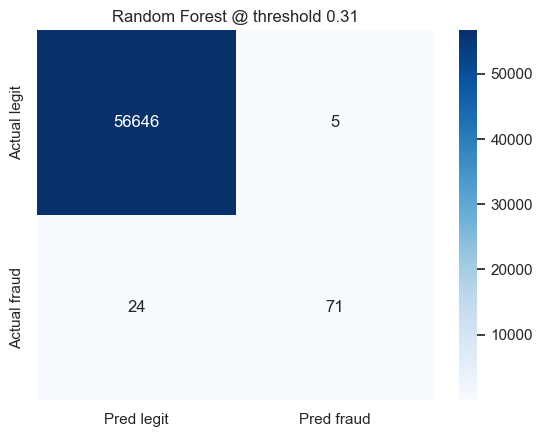

In [29]:
test_pred = (probas[best_name] >= best_threshold).astype(int)
print(classification_report(y_test, test_pred, target_names=["Legit", "Fraud"], digits=3))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred legit", "Pred fraud"], yticklabels=["Actual legit", "Actual fraud"])
plt.title(f"{best_name} @ threshold {best_threshold:.2f}")
plt.show()

## 8. Business impact
Translate the confusion matrix into money. The review cost per alert is an **assumption**. Change it to see how the trade-off shifts.

In [30]:
REVIEW_COST_PER_ALERT = 5.0  # assumed cost of a manual review

test_amount = df.loc[X_test.index, "Amount"]
is_fraud = y_test.values == 1
flagged = test_pred == 1

caught = test_amount[is_fraud & flagged].sum()
missed = test_amount[is_fraud & ~flagged].sum()
false_alerts = (~is_fraud & flagged).sum()

print(f"Fraud value in test set: {test_amount[is_fraud].sum():,.2f}")
print(f"Fraud value caught:      {caught:,.2f} ({caught / test_amount[is_fraud].sum():.1%})")
print(f"Fraud value missed:      {missed:,.2f}")
print(f"False alerts:            {false_alerts}  (review cost ≈ {false_alerts * REVIEW_COST_PER_ALERT:,.2f})")

Fraud value in test set: 14,766.31
Fraud value caught:      10,714.78 (72.6%)
Fraud value missed:      4,051.53
False alerts:            5  (review cost ≈ 25.00)


## 9. Feature importance (permutation importance on the test set)

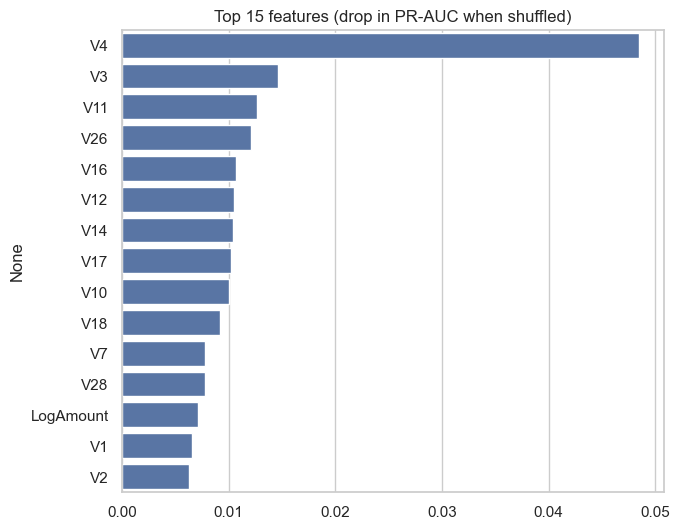

In [31]:
perm = permutation_importance(best_model, X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Top 15 features (drop in PR-AUC when shuffled)")
plt.show()

## 10. Save the model and test-set predictions

In [32]:
joblib.dump({"model": best_model, "threshold": best_threshold, "features": features}, "fraud_model.joblib")

predictions = pd.DataFrame({
    "transaction_id": X_test.index,
    "model_name": best_name,
    "fraud_probability": probas[best_name],
    "predicted_label": test_pred,
    "threshold": best_threshold,
})
predictions.to_csv("test_predictions.csv", index=False)
predictions.head()

,transaction_id,model_name,fraud_probability,predicted_label,threshold
0,86249,Random Forest,0.0,0,0.309779
1,250634,Random Forest,0.0,0,0.309779
2,20163,Random Forest,0.0,0,0.309779
3,68688,Random Forest,0.0,0,0.309779
4,191151,Random Forest,0.0,0,0.309779


## 11. Load data into MySQL
1. Run `sql/schema.sql` in MySQL to create the `fraud_db` database and tables.
2. `pip install sqlalchemy pymysql`
3. Put your credentials below (don't commit real passwords; use an environment variable).

Then run `sql/analysis_queries.sql` for the transaction analytics.

In [45]:
import os
from sqlalchemy import create_engine

from sqlalchemy.engine import URL

MYSQL_URL = URL.create(
    "mysql+pymysql",
    username="root",
    password=os.getenv("MYSQL_PASSWORD", "password"),
    host="localhost",
    port=3306,
    database="fraud_db",
)
engine = create_engine(MYSQL_URL)
tx = df.rename(columns={"Time": "time_seconds", "Hour": "hour_of_day", "Day": "day_num",
                        "Amount": "amount", "Class": "is_fraud"})
tx.insert(0, "transaction_id", df.index)
tx = tx[["transaction_id", "time_seconds", "hour_of_day", "day_num", "amount"]
        + [f"V{i}" for i in range(1, 29)] + ["is_fraud"]]

tx.to_sql("transactions", engine, if_exists="append", index=False, chunksize=10000, method="multi")
predictions.to_sql("predictions", engine, if_exists="append", index=False, chunksize=10000, method="multi")
print("Loaded", len(tx), "transactions and", len(predictions), "predictions")

Loaded 283726 transactions and 56746 predictions


In [47]:
# Quick check: run one of the analysis queries from Python
pd.read_sql("""
    SELECT hour_of_day, COUNT(*) AS txns, SUM(is_fraud) AS frauds,
           ROUND(100 * AVG(is_fraud), 3) AS fraud_rate_pct
    FROM transactions
    GROUP BY hour_of_day
    ORDER BY fraud_rate_pct DESC
    LIMIT 5
""", engine)

,hour_of_day,txns,frauds,fraud_rate_pct
0,2,3308,48.0,1.45
1,4,2204,23.0,1.04
2,3,3487,17.0,0.49
3,5,2988,11.0,0.37
4,7,7233,23.0,0.32


## 12. Conclusions

**Best model: Random Forest** (class-weighted, 200 trees)
- 5-fold CV PR-AUC: **0.840 ± 0.034**, vs 0.756 (Logistic Regression) and 0.748 (Gradient Boosting)
- Test set at tuned threshold (0.31): **precision 0.934, recall 0.747, F1 0.830**
- Caught **71 of 95 frauds** with only **5 false alerts** out of 56,651 legitimate transactions
- Caught **72.6% of fraudulent transaction value** (10,715 of 14,766)

**Model comparison insights**
- ROC-AUC was 0.94–0.97 for all three models and could not separate them; PR-AUC (0.68–0.81 on test) clearly could. At the default threshold, Logistic Regression raised 1,434 false alarms vs Random Forest's 3.
- Threshold tuning on out-of-fold predictions (0.5 → 0.31) added 2 caught frauds for 2 extra false alerts. Model choice mattered far more than threshold.

**Fraud patterns**
- Overall fraud rate is 0.17%, but in hour 2 of the recording window it reaches **1.45% (~9× higher)**. The five riskiest hours are all low-volume, likely night-time hours.
- Most important features (permutation importance): **V4, V3, V11, V26, V16**. V4 dominates: shuffling it drops PR-AUC by ~0.05, over 3× more than any other feature. LogAmount ranks 13th, and the hour feature isn't in the top 15, so the model relies mainly on the PCA features.

**Limitations**
- V1–V28 are anonymised PCA components, so they can't be explained in business terms
- Only 2 days of data; `Time` is relative, not real clock time
- Only 95 frauds in the test set: each one shifts recall by ~1%, so metrics are noisy
- 24 frauds (27% of fraud value) were still missed. Next steps: richer features (customer history, merchant), cost-sensitive thresholds